Loading and preprocessing data...


C:\Users\2linm\AppData\Local\Temp\ipykernel_11412\1480427794.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_subset = df.groupby('year_quarter', group_keys=False).apply(


Final subset size: 5244 records


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing text...


...

Clustering...


C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


Extracting topic keywords...


Labeling topics: 100%|██████████| 8/8 [02:27<00:00, 18.42s/it]


Generating quarterly trends...


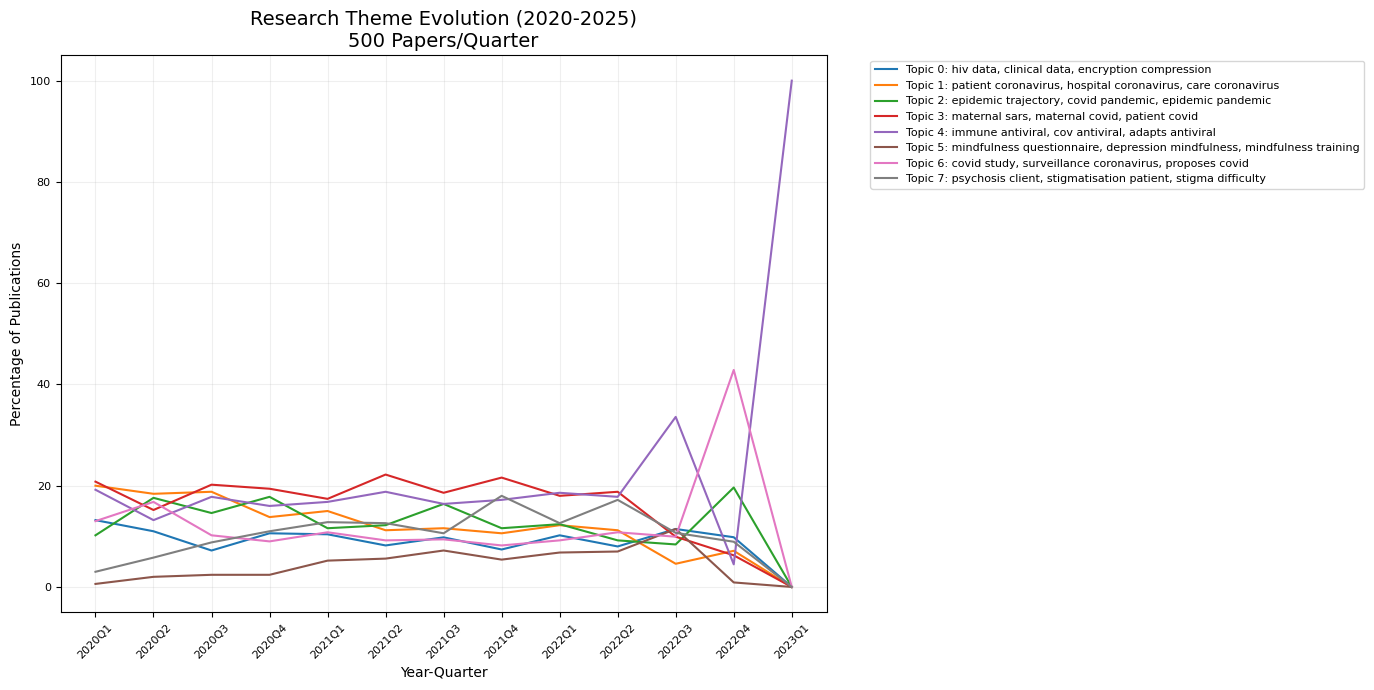

In [2]:
# Imports and Libraries
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.cluster import MiniBatchKMeans
import umap
from keybert import KeyBERT
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
import torch
from tqdm import tqdm

# Line
# Data Preprocessing
print("Loading and preprocessing data...")
df = pd.read_csv('cp421/metadata.csv', low_memory=False)

# Extracting only relevant fields
df = df[['title', 'abstract', 'publish_time', 'authors']]
df = df.dropna(subset=['abstract', 'publish_time'])
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df = df.dropna(subset=['publish_time'])
df = df[df['publish_time'].dt.year.between(2020, 2025)]
df['year_quarter'] = df['publish_time'].dt.to_period('Q')

# taking 500 records per quarter
df_subset = df.groupby('year_quarter', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=1)
)
print(f"Final subset size: {len(df_subset)} records")

# NLP tools: word lemmatizers, leading stopwords etc.
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')
lemmatizer = WordNetLemmatizer()

# Functions that cleans the text
def preprocess_text(text):
    text = str(text)
    text = re.sub(r'\d+', '', text.lower())  # early removal of numbers values
    tokens = tokenizer.tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Parallel processing for text cleaning
print("Preprocessing text...")
df_subset['processed_text'] = df_subset['title'] + " " + df_subset['abstract']
df_subset['processed_text'] = df_subset['processed_text'].apply(preprocess_text)

# Bert Topic Modelling
# Initialize SciBERT via caching
model_name = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to('cuda' if torch.cuda.is_available() else 'cpu')

# Getting batch embeddings
def get_embeddings(texts, batch_size=64): 
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True, 
                         max_length=128, add_special_tokens=True).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # the CLS token
        embeddings.append(batch_embeddings)
    return np.vstack(embeddings)

embeddings = get_embeddings(df_subset['processed_text'].tolist())

# Dimensionality reduction
print("Reducing dimensions...")
umap_embeddings = umap.UMAP(n_components=10, random_state=42,  # should increase components for better separation
                           n_neighbors=15, min_dist=0.1).fit_transform(embeddings)

# Clustering
print("Clustering...")
kmeans = MiniBatchKMeans(n_clusters=8, random_state=42, batch_size=1024)  # reduced clusters
df_subset['cluster'] = kmeans.fit_predict(umap_embeddings)

# Topic Labeling
print("Extracting topic keywords...")
kw_model = KeyBERT()
topic_labels = {}

for cluster in tqdm(sorted(df_subset['cluster'].unique()), desc="Labeling topics"):
    cluster_texts = df_subset[df_subset['cluster'] == cluster]['processed_text']
    # Should use smaller sample and shorter texts for faster processing
    sample_texts = cluster_texts.sample(min(100, len(cluster_texts)), random_state=42).tolist()
    sample_texts = [t[:1000] for t in sample_texts]  # must truncate long texts
    keywords = kw_model.extract_keywords(
        " ".join(sample_texts),
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=3  # should reduce # of keywords for cleaner labels
    )
    topic_labels[cluster] = f"Topic {cluster}: " + ", ".join([kw[0] for kw in keywords])

df_subset['topic_label'] = df_subset['cluster'].map(topic_labels)

# The Line Chart
print("Generating quarterly trends...")
trend_data = df_subset.groupby(['year_quarter', 'topic_label']).size().unstack().fillna(0)
trend_data = trend_data.div(trend_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 7))
for topic in trend_data.columns:
    plt.plot(trend_data.index.astype(str), trend_data[topic], label=topic, linewidth=1.5)

plt.title("Research Theme Evolution (2020-2025)\n500 Papers/Quarter", fontsize=14)
plt.ylabel("Percentage of Publications", fontsize=10)
plt.xlabel("Year-Quarter", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Loading and preprocessing data...

Date range in data: 2020-01-01 to 2023-01-01

Papers per quarter before sampling:
year_quarter
2020Q1    148039
2020Q2     32412
2020Q3     41403
2020Q4     38582
2021Q1    227054
2021Q2     46569
2021Q3     45446
2021Q4     46825
2022Q1     85050
2022Q2     25581
2022Q3       131
2022Q4       112
2023Q1        17
Freq: Q-DEC, Name: count, dtype: int64


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Final subset size: 5260 records

Papers per quarter after sampling:
year_quarter
2020Q1    500
2020Q2    500
2020Q3    500
2020Q4    500
2021Q1    500
2021Q2    500
2021Q3    500
2021Q4    500
2022Q1    500
2022Q2    500
2022Q3    131
2022Q4    112
2023Q1     17
Freq: Q-DEC, Name: count, dtype: int64

Preprocessing text...


100%|██████████| 5260/5260 [00:08<00:00, 653.19it/s]



Initializing BERT model...


...


Reducing dimensions...


C:\anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering...

Labeling topics...


C:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
Topics: 100%|██████████| 8/8 [02:12<00:00, 16.50s/it]



Generating visualization...


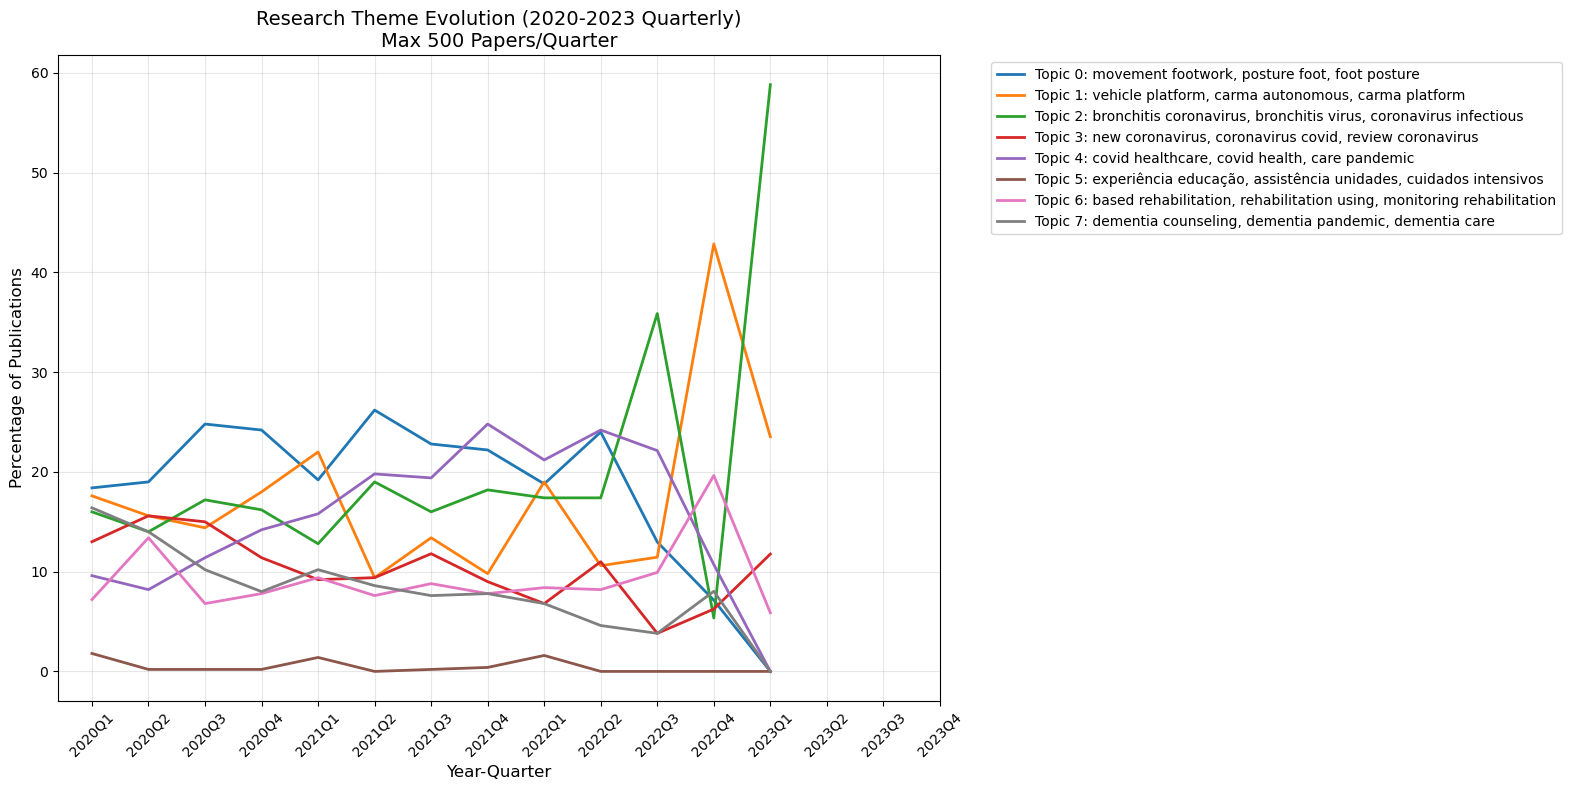

In [17]:
# activating tqdm for pandas
tqdm.pandas()

# loading and preprocessing
print("Loading and preprocessing data...")
df = pd.read_csv('cp421/metadata.csv', low_memory=False)
df = df[['title', 'abstract', 'publish_time', 'authors']].dropna(subset=['abstract', 'publish_time'])

# dynamic date handling
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce', format='mixed')
df = df.dropna(subset=['publish_time'])
df = df[df['publish_time'].dt.year.between(2020, 2023)]  # Adjusted to ensure complete quarters
df['year_quarter'] = df['publish_time'].dt.to_period('Q')

# verify date ranges
print(f"\nDate range in data: {df['publish_time'].min().date()} to {df['publish_time'].max().date()}")
quarter_counts = df['year_quarter'].value_counts().sort_index()
print("\nPapers per quarter before sampling:")
print(quarter_counts)

# Sample up to 500 papers per quarter
df_subset = pd.concat([
    df[df['year_quarter'] == quarter].sample(n=min(500, len(df[df['year_quarter'] == quarter])), random_state=1)
    for quarter in quarter_counts.index
])
print(f"\nFinal subset size: {len(df_subset)} records")
print("\nPapers per quarter after sampling:")
print(df_subset['year_quarter'].value_counts().sort_index())

nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)
    text = re.sub(r'\d+', '', text.lower())
    tokens = tokenizer.tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

print("\nPreprocessing text...")
df_subset['processed_text'] = (df_subset['title'] + " " + df_subset['abstract']).progress_apply(preprocess_text)

# topic modeling
print("\nInitializing BERT model...")
model_name = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to('cuda' if torch.cuda.is_available() else 'cpu')

def get_embeddings(texts, batch_size=64):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=128).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings.append(outputs.last_hidden_state[:,0,:].cpu().numpy())
    return np.vstack(embeddings)

embeddings = get_embeddings(df_subset['processed_text'].tolist())

print("\nReducing dimensions...")
umap_embeddings = umap.UMAP(n_components=10, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(embeddings)

print("Clustering...")
kmeans = MiniBatchKMeans(n_clusters=8, random_state=42, batch_size=1024)
df_subset['cluster'] = kmeans.fit_predict(umap_embeddings)

# Topic labeling
print("\nLabeling topics...")
kw_model = KeyBERT()
topic_labels = {}

for cluster in tqdm(sorted(df_subset['cluster'].unique()), desc="Topics"):
    cluster_texts = df_subset[df_subset['cluster'] == cluster]['processed_text']
    sample_texts = cluster_texts.sample(min(100, len(cluster_texts)), random_state=42).tolist()
    sample_texts = [t[:1000] for t in sample_texts]
    keywords = kw_model.extract_keywords(" ".join(sample_texts), keyphrase_ngram_range=(1,2), top_n=3)
    topic_labels[cluster] = f"Topic {cluster}: " + ", ".join([kw[0] for kw in keywords])

df_subset['topic_label'] = df_subset['cluster'].map(topic_labels)

# Plotting Line Chart
print("\nGenerating visualization...")
trend_data = df_subset.groupby(['year_quarter', 'topic_label']).size().unstack().fillna(0)
trend_data = (trend_data.div(trend_data.sum(axis=1), axis=0) * 100).sort_index()

plt.figure(figsize=(16, 8))
for topic in trend_data.columns:
    plt.plot(trend_data.index.astype(str), trend_data[topic], label=topic, linewidth=2)

all_quarters = pd.period_range(start='2020Q1', end='2023Q4', freq='Q') # making sure all quarters appear on axis
plt.xticks(ticks=range(len(all_quarters)), labels=[str(q) for q in all_quarters], rotation=45)

plt.title("Research Theme Evolution (2020-2023 Quarterly)\nMax 500 Papers/Quarter", fontsize=14)
plt.ylabel("Percentage of Publications", fontsize=12)
plt.xlabel("Year-Quarter", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Strange Anomalies I found while sifting through the dataset.

In [19]:
# Import necessary libraries
import pandas as pd

# check number of articles between 2020 and 2025
# load and preprocess the data
print("Loading metadata.csv...")
df = pd.read_csv('cp421/metadata.csv', low_memory=False)
df = df[['title', 'abstract', 'publish_time', 'authors']]
df = df.dropna(subset=['abstract', 'publish_time'])
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df = df.dropna(subset=['publish_time'])

# convert to year/quarter format
df['year_quarter'] = df['publish_time'].dt.to_period('Q')

# filter for 2020-2025 articles only
df = df[df['publish_time'].dt.year.between(2020, 2025)]

# scan for available quarters
print("Available quarters in the dataset:")
quarter_counts = df['year_quarter'].value_counts().sort_index()
print(quarter_counts)

# specifically check if data exists beyond 2023Q1
cutoff = pd.Period('2023Q1', freq='Q')
has_later_data = any(q > cutoff for q in df['year_quarter'].unique())
if has_later_data:
    latest_quarter = df['year_quarter'].max()
    print(f"\nYes, the dataset has data beyond 2023Q1. Latest quarter: {latest_quarter}")
else:
    print("\nNo, the dataset does not contain data beyond 2023Q1.")

Loading metadata.csv...
Available quarters in the dataset:
year_quarter
2020Q1     6040
2020Q2    32412
2020Q3    41403
2020Q4    38582
2021Q1    43537
2021Q2    46569
2021Q3    45446
2021Q4    46825
2022Q1    48425
2022Q2    25581
2022Q3      131
2022Q4      112
2023Q1        1
Freq: Q-DEC, Name: count, dtype: int64

No, the dataset does not contain data beyond 2023Q1.


In [25]:
import pandas as pd

# simple check that checks whether data exists beyond 2023Q2 
df = pd.read_csv('cp421/metadata.csv', usecols=['publish_time'], low_memory=False)
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df = df[df['publish_time'].dt.year.between(2020, 2025)]
cutoff = pd.Period('2023Q2', freq='Q')
has_later_data = (df['publish_time'].dt.to_period('Q') > cutoff).any()
print("Data exists beyond 2023Q2:" if has_later_data else "No data beyond 2023Q2.")

Data exists beyond 2023Q2:


In [27]:
import pandas as pd

# Checking how many total articles between 2023Q1 and 2024Q4
df = pd.read_csv('cp421/metadata.csv', usecols=['publish_time'], low_memory=False)
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df = df[df['publish_time'].dt.year.isin([2023, 2024])]
df['quarter'] = df['publish_time'].dt.to_period('Q')
counts = df['quarter'].value_counts().sort_index()
print("Articles per quarter in 2023 and 2024:")
print(counts)
total = counts.sum()
print(f"\nTotal articles in 2023 and 2024: {total}")

Articles per quarter in 2023 and 2024:
quarter
2023Q1    1
2024Q2    1
Freq: Q-DEC, Name: count, dtype: int64

Total articles in 2023 and 2024: 2


In [29]:
import pandas as pd

# Confirming my suspicions: Checking for any Covid related articles exist beyond 2022Q4
# load data with only necessary columns (publish_time)
df = pd.read_csv('cp421/metadata.csv', usecols=['publish_time', 'title', 'abstract'], low_memory=False)
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df = df[df['publish_time'].dt.year.isin([2023, 2024])].dropna(subset=['title', 'abstract'])

# convert to quarters
df['quarter'] = df['publish_time'].dt.to_period('Q')

# define COVID-related keywords
covid_keywords = {'covid', 'coronavirus', 'sars-cov-', 'pandemic', 'lockdown', 'vaccin', 'quarantine', 'epidemic'}

# word check to see if it is COVID-related
def is_covid_related(text):
    text = str(text).lower()
    return any(keyword in text for keyword in covid_keywords)

# check each article
df['is_covid'] = (df['title'] + " " + df['abstract']).apply(is_covid_related)

# tally up COVID-related articles per quarter
covid_counts = df[df['is_covid']].groupby('quarter').size()
total_covid = covid_counts.sum()
total_articles = df['quarter'].value_counts().sort_index()

# results
print("Articles per quarter in 2023 and 2024 (with COVID-related counts):")
for quarter in total_articles.index:
    covid_num = covid_counts.get(quarter, 0)
    total_num = total_articles[quarter]
    print(f"{quarter}: {total_num} total, {covid_num} COVID-related")
print(f"\nTotal articles in 2023 and 2024: {total_articles.sum()}")
print(f"Total COVID-related articles: {total_covid}")
print("COVID-related articles found!" if total_covid > 0 else "No COVID-related articles found.")

Articles per quarter in 2023 and 2024 (with COVID-related counts):
2023Q1: 1 total, 0 COVID-related

Total articles in 2023 and 2024: 1
Total COVID-related articles: 0
No COVID-related articles found.


C:\Users\2linm\AppData\Local\Temp\ipykernel_6420\3116874398.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_subset = df.groupby('year_quarter', group_keys=False).apply(stratified_sample)
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\2linm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Generating embeddings: 100%|██████████| 295/295 [48:29<00:00,  9.86s/it] 
C:\anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. U

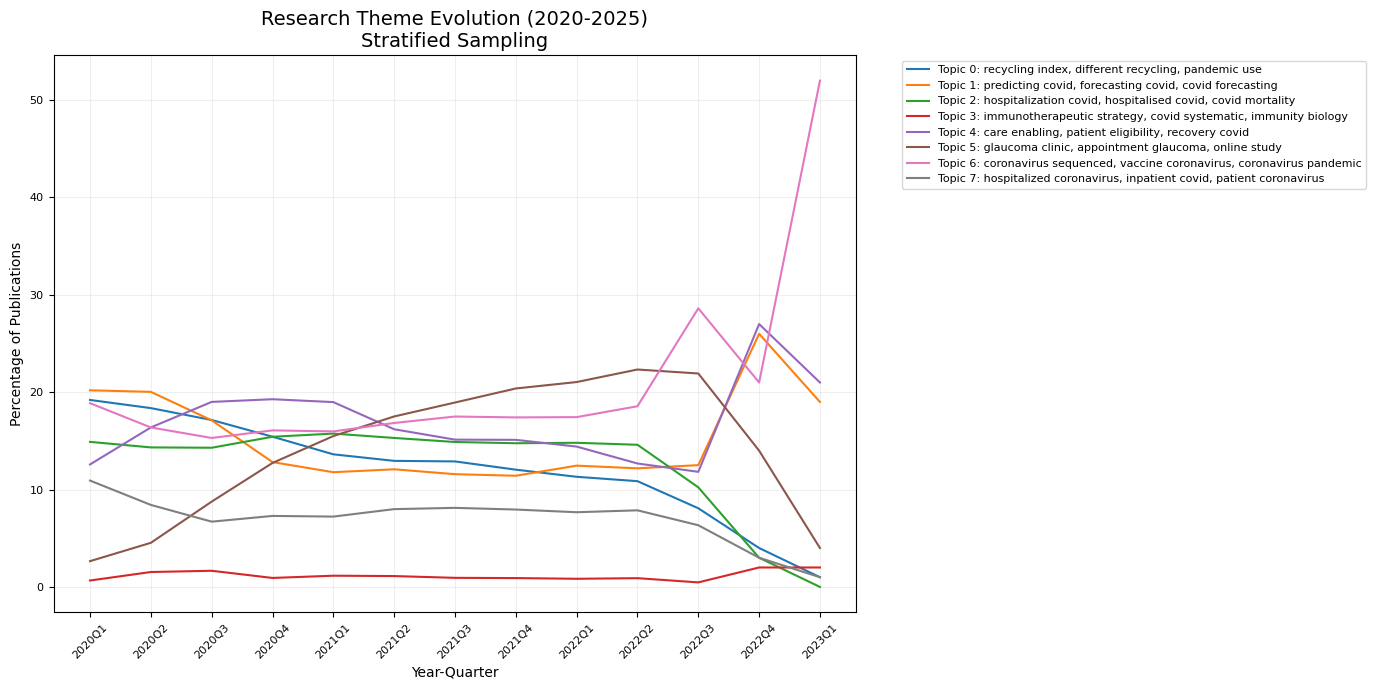

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import textwrap
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.cluster import MiniBatchKMeans
import umap
from keybert import KeyBERT
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
import torch
from tqdm import tqdm

# Linechart using Stratified Sampling over a fixed sampling size.
# Load and preprocess data
df = pd.read_csv('cp421/metadata.csv', low_memory=False)
df = df[['title', 'abstract', 'publish_time', 'authors']].dropna(subset=['abstract', 'publish_time'])
df['publish_time'] = pd.to_datetime(df['publish_time'], errors='coerce')
df = df[df['publish_time'].dt.year.between(2020, 2025)]
df['year_quarter'] = df['publish_time'].dt.to_period('Q')

# Stratified Sampling (5% per quarter)
def stratified_sample(group, frac=0.05, min_samples=50):
    n = max(int(len(group) * frac), min_samples)
    return group.sample(n=min(n, len(group)), random_state=1)

df_subset = df.groupby('year_quarter', group_keys=False).apply(stratified_sample)

# NLP Preprocessing
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    tokens = tokenizer.tokenize(text)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

df_subset['processed_text'] = df_subset['title'] + " " + df_subset['abstract']
df_subset['processed_text'] = df_subset['processed_text'].apply(preprocess_text)

# preparing SciBERT
model_name = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to('cuda' if torch.cuda.is_available() else 'cpu')

# Generate Embeddings
def get_embeddings(texts, batch_size=64):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True, max_length=128).to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
        embeddings.append(outputs.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(embeddings)

embeddings = get_embeddings(df_subset['processed_text'].tolist())

# Dimensionality Reduction via UMAP
umap_embeddings = umap.UMAP(n_components=20, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(embeddings)

# Clustering using MiniBatchKMeans
kmeans = MiniBatchKMeans(n_clusters=8, random_state=42, batch_size=1024)
df_subset['cluster'] = kmeans.fit_predict(umap_embeddings)

# Extract Topic Keywords (making it legible)
kw_model = KeyBERT()
topic_labels = {}

def truncate_text(text, max_length=1000):
    return textwrap.shorten(text, width=max_length, placeholder="...")

for cluster in sorted(df_subset['cluster'].unique()):
    cluster_texts = df_subset[df_subset['cluster'] == cluster]['processed_text']
    sample_texts = cluster_texts.sample(min(100, len(cluster_texts)), random_state=42).tolist()
    sample_texts = [truncate_text(t, max_length=1000) for t in sample_texts]
    keywords = kw_model.extract_keywords(" ".join(sample_texts), keyphrase_ngram_range=(1, 2), stop_words='english', top_n=3)
    topic_labels[cluster] = f"Topic {cluster}: " + ", ".join([kw[0] for kw in keywords])

df_subset['topic_label'] = df_subset['cluster'].map(topic_labels)

# Quarterly Trends
trend_data = df_subset.groupby(['year_quarter', 'topic_label']).size().unstack().fillna(0)
trend_data = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
trend_data = trend_data.rolling(2, min_periods=1).mean()  # Smoothing

# Plot
plt.figure(figsize=(14, 7))
for topic in trend_data.columns:
    plt.plot(trend_data.index.astype(str), trend_data[topic], label=topic, linewidth=1.5)

plt.title("Research Theme Evolution (2020-2025)\nStratified Sampling", fontsize=14)
plt.ylabel("Percentage of Publications", fontsize=10)
plt.xlabel("Year-Quarter", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
